# Titanic - Machine Learning from Disaster

| Variable  | Definition                                   | Key                                      |
|-----------|----------------------------------------------|------------------------------------------|
| survival  | Survival                                     | 0 = No, 1 = Yes                          |
| pclass    | Ticket class                                 | 1 = 1st, 2 = 2nd, 3 = 3rd                |
| sex       | Sex                                          |                                          |
| age       | Age in years                                 |                                          |
| sibsp     | # of siblings / spouses aboard the Titanic   |                                          |
| parch     | # of parents / children aboard the Titanic   |                                          |
| ticket    | Ticket number                                |                                          |
| fare      | Passenger fare                               |                                          |
| cabin     | Cabin number                                 |                                          |
| embarked  | Port of Embarkation                          | C = Cherbourg, Q = Queenstown, S = Southampton |

---
## Import Libraries

In [79]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split


---
## Read Files

In [80]:
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

---
## Explore the data

In [81]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [82]:
count_cabin = df_train['Cabin'].isnull().sum()
print(count_cabin, " null values")

687  null values


Based on this information this already gives us an idea of what might be interesting and what seems likely to be unnecessary. 

Things that might be unnecessary: 
- PassengerID,
- Cabin (too many null values, drop it)

This that might be interesting to keep: 
- Survived 
- Pclass (people with higher title have higher chance of survival?)
- Age

In [83]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


Age ==> Min age is a baby and the max age is 80 years old

Pclass ==> common class was the second class

In [84]:
# A summary of the categorical (text) columns
df_train.describe(include='O').T

C:\Users\fifif\AppData\Local\Temp\ipykernel_38648\3862125620.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_train.describe(include='O').T


,count,unique,top,freq
Name,891,891,"Braund, Mr. Owen Harris",1
Sex,891,2,male,577
Ticket,891,681,347082,7
Cabin,204,147,G6,4
Embarked,889,3,S,644


Note: Ticket has 681 unique values so does this mean that there are double in the tickets? 

Cabin can make sense because multiple people can be assigned to the same cabin


In [85]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [86]:
df_train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

There are missing values in age , cabin and embarked

Cabin number has the higest amount of missing values

This can be interesting if we want to remove certain columns or change them 

In [87]:
print(len(df_train))

891


---
###  Classes Likely to survive

- Ticket class : this will impact your likelyhood of survival. If you have a higher classs you might be closer to the exit
- Sex: This will def have an impact as Women and children and elderly are known to have a priority when it comes to disasters
- Age: Same things age does impact survivalhood children and elderly will be prioritised 

In [88]:
#Look if women actualy had a higher survival rate than men
(df_train.groupby('Sex')['Survived'].mean()*100).map("{:.2f}%".format)


Sex
female    74.20%
male      18.89%
Name: Survived, dtype: str

Women had a higher percentage of survival with a 74% whereas men its as low as 19%.

In [89]:
#Look if class actually had an impact on survival
(df_train.groupby('Pclass')['Survived'].mean()*100).map("{:2f}%".format)

Pclass
1    62.962963%
2    47.282609%
3    24.236253%
Name: Survived, dtype: str

Also confirms the hypothesis that the higher classes did have a higher likelyhood of surviving , the third class survival was to be only 24%

In [90]:
#Look if age had an impact on the survival rates.
bins = int((df_train['Age'].max() - df_train['Age'].min()) / 5)
print(round(bins, 3))

15


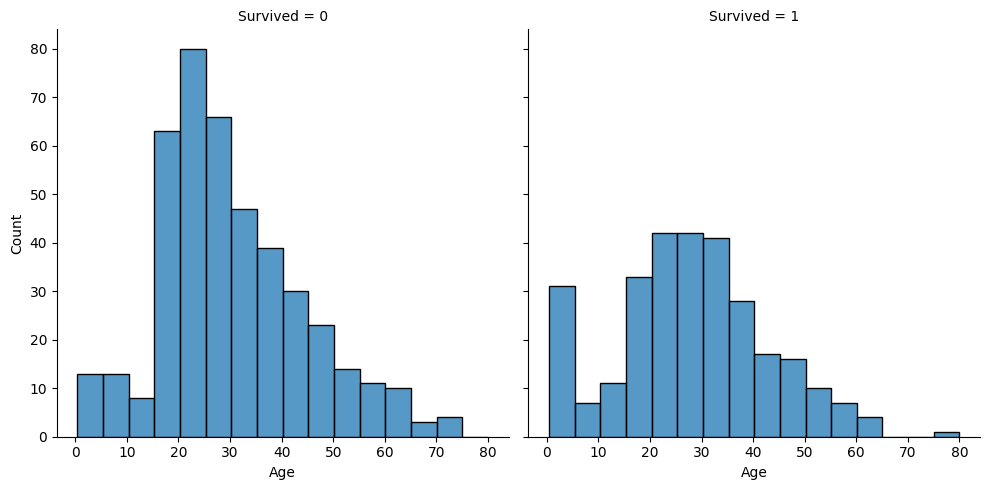

In [91]:
sns.displot(data=df_train, x='Age', col='Survived', bins=16)

Note: that people between 20 and 30 had the highest rates of not surviving the disaster

---

Look at the people who survived

In [92]:
df_train['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [93]:
survival_rate = df_train['Survived'].value_counts(normalize=True)
print((survival_rate * 100), "%")


Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64 %


Look at the balance between those who have survived and those who didn't
We see that 61% did not survive whereas 38% did survive the disaster

Within those people look at the title they have as this also impact. We already know that class has an impact but if we search further we can check if the title of a person also influenced or not?

Look if the groupsize actually matter in surving? 

To do this it's best to combine them to like at family size in general. 
By combining the total family size, which is what actually matters for survival. And we also add  one to count for the passenger itself

In [94]:
#combine both siblings and spouses and childeren
df_train['Family-size'] = df_train['SibSp'] + df_train['Parch'] + 1
df_test['Family-size'] = df_test['SibSp'] + df_test['Parch'] + 1


In [95]:
df_train.groupby('Family-size')['Survived'].mean()*100

Family-size
1     30.353818
2     55.279503
3     57.843137
4     72.413793
5     20.000000
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: Survived, dtype: float64

what we can see is that smaller/ midsize family have a higher change of survival so with a max of 4 members anything above that had a lower chance of surviving

In [96]:
df_train.groupby('SibSp')['Survived'].mean()*100

SibSp
0    34.539474
1    53.588517
2    46.428571
3    25.000000
4    16.666667
5     0.000000
8     0.000000
Name: Survived, dtype: float64

Map to family to its size. 

In [97]:
df_train.groupby('Ticket')['Survived'].mean()*100

Ticket
110152         100.000000
110413          66.666667
110465           0.000000
110564         100.000000
110813         100.000000
                  ...    
W./C. 6608       0.000000
W./C. 6609       0.000000
W.E.P. 5734      0.000000
W/C 14208        0.000000
WE/P 5735       50.000000
Name: Survived, Length: 681, dtype: float64

Data Cleaning: 
Based on the findings the data needs some cleaning some things will be dropped other will be filled
- Cabin --> drop because it has a lot of missing values
- Age --> fill with the median 
- Embarked --> fill with mode only 2 are missing
- PassengerId, Name, Ticket --> drop (not predictive)

In [98]:
def clean_data(df):
    df = df.copy()

    #Drop columns with too many missing values or no predictive value
    df.drop(columns=['Cabin', 'PassengerId', 'Name', 'Ticket'], inplace=True)
    #inplace=True -->change the original df directly instead of creating a new one

    #Fill missing Age with median
    df['Age'] =  df['Age'].fillna(df['Age'].median(), inplace=True)

    #Fill missing Embarked with mode (most frequent value)
    df['Embarked'] =  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
    #mode gives the most frequent value , 0 takes the first value from that result
    # in case there are mutliple modes it will take the first one 

    #Fill missing Fare (only in test set) with median
    df['Fare'] =  df['Fare'].fillna(df['Fare'].median(), inplace=True)

    return df
#return sends the cleaned df back out of the function
# inside the def all changes happen to a local variable without 
#the return df, those changes stay inside the function and cannot use them outside


In [99]:
df_train_clean = clean_data(df_train)
df_test_clean = clean_data(df_test)

C:\Users\fifif\AppData\Local\Temp\ipykernel_38648\1235888367.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'] =  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\fifif\AppData\Local\Temp\ipykernel_38648\1235888367.py:12: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through ch

In [100]:
#Quick check : should show 0 missing values for all columns
print("Train missing values: \n", df_train_clean.isnull().sum())
print("\nTest missing values: \n", df_test_clean.isnull().sum())

Train missing values: 
 Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
Family-size    0
dtype: int64

Test missing values: 
 Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
Family-size    0
dtype: int64


---

Encoding Categorical Variables
Goal is to convert text (Sex, Embarked) into numbers, because ML models only understand numbers

In [101]:
def encode_data(df):
    df = df.copy()

    #Sex: male --> 0, female --> 1
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

    #Embarked: S --> 0, C --> 1, Q --> 2
    df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

    return df

In [102]:
df_train_clean = encode_data(df_train_clean)
df_test_clean = encode_data(df_test_clean)

In [103]:
#Quick check
print(df_train_clean[['Sex', 'Embarked']].head())
print(df_train_clean.dtypes)

   Sex  Embarked
0    0         0
1    1         1
2    1         0
3    1         0
4    0         0
Survived         int64
Pclass           int64
Sex              int64
Age            float64
SibSp            int64
Parch            int64
Fare           float64
Embarked         int64
Family-size      int64
dtype: object


---

## Building model

First try with logitic regression it's the simplest classification model and thus makes a good baseline and works well with linear relationship (like survival, whuch we saw in the EDA)

Will use crossvalition 5 times, instead of splittings the data once in train and test it will split 5 times and averages the results (gives us a more reliable estimate and prevents getting lucky)

Normally the default iterations is 100 but I'll increase to 1000 to make sure it finished properly 

In [104]:
#Define features and target

X = df_train_clean.drop(columns=['Survived'])
y = df_train_clean['Survived']

Normally the iteration is 100 but for this dataset it might stop too early, results can be less accurate 

In [105]:
#Train Logistic Regression using 5 folds cross validation

lr_model = LogisticRegression(max_iter=1000)
lr_scores = cross_val_score(lr_model, X, y, cv=5, scoring='accuracy')

In [106]:
print("Logistic Regression CV scores: ", lr_scores)
print("Mean Accuracy: ", round(lr_scores.mean(), 4))
print("Std Deviation: ", round(lr_scores.std(), 4))

Logistic Regression CV scores:  [0.79329609 0.79213483 0.78651685 0.76966292 0.8258427 ]
Mean Accuracy:  0.7935
Std Deviation:  0.0182


An overall performance of 79,35% 
the standard deviaton shows us how much the scores vary between the folds, here we have a low devation which hints to being a stable model

---

### Other models

So we create a random forest model with 100 trees, and evaluate using a 5 fold cross validation and measure accuracy on each split. 

For the random forest it combines many decision trees A decision tree makes predictions by questions like: 
- is Age <30?
- is Sex = Female? 
A random forest builds many of these trees and combines their predictions.

In [107]:
#Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')

In [108]:
print("Random Forest CV scores: ", rf_scores)
print("Mean Accuracy: ", round(rf_scores.mean(), 4))
print("Sted Dev: ", round(rf_scores.std(), 4))

Random Forest CV scores:  [0.78212291 0.80337079 0.84831461 0.79213483 0.8258427 ]
Mean Accuracy:  0.8104
Sted Dev:  0.0239


The average mean is 81%
And if we compare it with the logistic model it's a higher accuracy.
But the sted dev is higher than the logistic one

In [109]:
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_scores = cross_val_score(gb_model, X, y, cv=5, scoring='accuracy')

Gradient boosting is another model that combines many small decisions trees, but it works different from Random Forest
Instead of building trees independently, it builds them one after another, where each new tree tries to fix the mistakes of the previous ones. 

In [110]:
print("\nGradient Boosting CV scores:", gb_scores)
print("Mean accuracy: ", round(gb_scores.mean(), 4))
print("sted dev: ", round(gb_scores.std(), 4))


Gradient Boosting CV scores: [0.81564246 0.80898876 0.84269663 0.79775281 0.86516854]
Mean accuracy:  0.826
sted dev:  0.0245


here we get an average accuracy of 82.6% which now outperforms the two other models and when we look at the sted dev it is higher than the two previous ones but still somewhat table. 

So far this gives the highest accuracy but has a slightly higher variation 

---

## Hyperparameter Tuning

Hyperparameter tuning helps us find the best setting for our model. Here we're going to try with GridSearch and it will give us the best setting. 


In [111]:
param_grid = {
    'n_estimators': [100,200], #number of trees
    'max_depth': [3,4,5], #controls the model complexity
    'learning_rate': [0.05, 0.1, 0.2] #controls how much each tree contributes
}

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring = 'accuracy'
)

grid_search.fit(X,y)

print("Best parameters: ", grid_search.best_params_)
print("Best accuracy: ", round(grid_search.best_score_, 4))

Best parameters:  {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100}
Best accuracy:  0.8373


---

## Step 5: Model Evaluation

Here we look at how the model performs

Split data into train and test sets

In [112]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

train best model

In [113]:
best_model = GradientBoostingClassifier(
    learning_rate=0.2, max_depth=3, n_estimators=100, random_state=42
)

In [114]:
best_model.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.2
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [115]:
y_pred = best_model.predict(X_test)

In [116]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.90      0.88       105
           1       0.85      0.81      0.83        74

    accuracy                           0.86       179
   macro avg       0.86      0.85      0.86       179
weighted avg       0.86      0.86      0.86       179



Classification report:

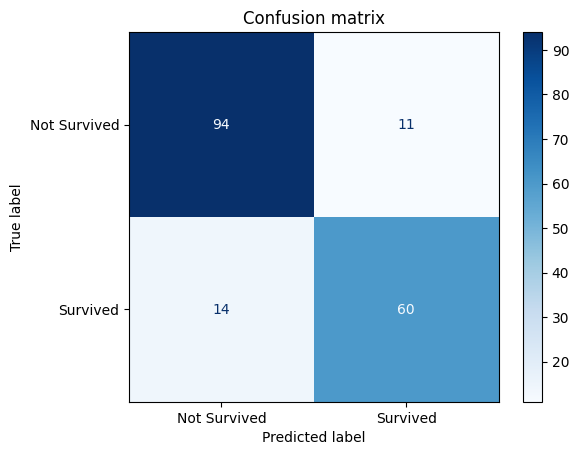

In [117]:
confm = confusion_matrix(y_test, y_pred)
displ = ConfusionMatrixDisplay(confusion_matrix=confm, display_labels=['Not Survived', 'Survived'])
displ.plot(cmap="Blues")
plt.title("Confusion matrix")
plt.show()

---

## 6: Feature importance

In [118]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

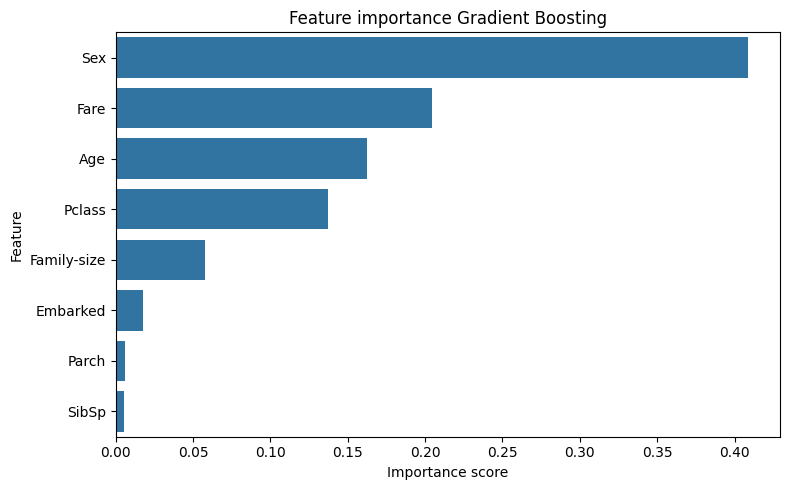

In [119]:
plt.figure(figsize=(8,5))
sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.title("Feature importance Gradient Boosting")
plt.xlabel("Importance score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [120]:
print(feature_importance)

Sex            0.408943
Fare           0.204201
Age            0.162479
Pclass         0.137455
Family-size    0.057709
Embarked       0.017725
Parch          0.006220
SibSp          0.005269
dtype: float64


This tells us the following: 
- Sex being the highest shows that it has influenced the most (female higher chance of survival)
- fare : the higher the fare the better the survival
- age : children were prioritised
- Pclass: higher class --> better survival
- family-size : small/mid families survived more
- Embarked / Parch / SibSp : low to no impact. 

Sources to cite:

Pandas documentation: pandas.pydata.org/docs
Scikit-learn documentation: scikit-learn.org/stable
Seaborn documentation: seaborn.pydata.org
Kaggle Titanic dataset: kaggle.com/c/titanic

AI tools used:

Claude (Anthropic) — used for step by step guidance on data cleaning, model building and evaluation

In [121]:
# kaggle submission
test_predictions = best_model.predict(df_test_clean)

submission = pd.DataFrame(
    {
        'PassengerId': pd.read_csv('test.csv')['PassengerId'],
        'Survived': test_predictions
    }
)


submission.to_csv('submission1.csv', index=False)
print(submission.head(10))
print("Submission file saved!")

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         0
5          897         0
6          898         0
7          899         0
8          900         1
9          901         0
Submission file saved!
